## Image Cleaning - Open CV for CIFAR-10

The objective of this Python notebook is to compare 5 different Image Cleaning techniques on the Keras CIFAR-10 dataset, via OpenCV.

The methods used here are:
- No Processing
- Canny Edge Detection
- Gaussian Blur
- Contrast Enhancement
- Cropping

Note that RNNs are sequential models, so they're expected to do poorly on datasets like CIFAR-10, which consist of image data. However, we're retaining the RNN as the model here for comparison purposes with the MNIST notebook.

In [1]:
import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

from keras.datasets import cifar10

In [2]:
(trainImg, trainLabel), (testImg, testLabel) = cifar10.load_data()

print(trainLabel.shape, testLabel.shape)

(50000, 1) (10000, 1)


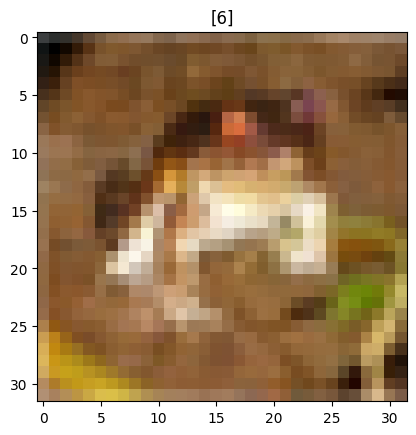

In [3]:
image = trainImg[0]
label = trainLabel[0]

plt.imshow(image)
plt.title(label)
plt.show()

## Image Cleaning Methods

In [4]:
# Method 1 - No Cleaning

def noClean(img):
  return img

In [5]:
# Method 2 - Canny Edge Detection
# This is a commonly used algorithm, in-built in OpenCV, which detects the outlines of the objects within the image.

def cannyEdgeMethod(img):
  return cv2.cvtColor(cv2.Canny(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 50, 150), cv2.COLOR_GRAY2RGB)

In [6]:
# Method 3 - Gaussian Blurring
# This reduces noise by smoothing the image.

def gaussianBlurMethod(img):
  return cv2.GaussianBlur(img, (5, 5), 0)

In [7]:
# Method 4 - Contrast Adjustment
# This enhances the contrast of the image to increase visibility of the features.

def contrastMethod(img):
  return cv2.cvtColor(cv2.equalizeHist(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)), cv2.COLOR_GRAY2RGB)

In [8]:
# Method 5 - Crop
# Cropping to focus on the object in the image.

def cropMethod(img):
  img = img[2:30, 2:30]
  return cv2.resize(img, (32, 32))

## Simple RNN Model

In [9]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam

def initRNN():
    model = Sequential([SimpleRNN(128, input_shape=(32, 96)), Dense(10, activation="softmax")])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [10]:
# Need to make labels Categorical for RNN
from keras.utils import to_categorical

trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical = to_categorical(testLabel, 10)

In [11]:
def comparisonModels(cleaningMethod):
  # Apply cleaning method to each image in train/test set
  trainImg2 = np.array([cleaningMethod(img) for img in trainImg])
  testImg2 = np.array([cleaningMethod(img) for img in testImg])

  # Normalising and re-shaping the images
  trainImg2 = (trainImg2/255.0)
  trainImg2 = trainImg2.reshape((trainImg2.shape[0], 32, 96))
  testImg2 = (testImg2/255.0)
  testImg2 = testImg2.reshape((testImg2.shape[0], 32, 96))

  # RNN Model
  model = initRNN()
  model.fit(trainImg2, trainLabelCategorical, epochs=5, batch_size=64)

  return model.evaluate(testImg2, testLabelCategorical)

## Evaluation

In [12]:
modelNoCleaning = comparisonModels(noClean)
modelCanny = comparisonModels(cannyEdgeMethod)
modelGaussianBlur = comparisonModels(gaussianBlurMethod)
modelContrast = comparisonModels(contrastMethod)
modelCrop = comparisonModels(cropMethod)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.2418 - loss: 2.0520
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3245 - loss: 1.8513
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.3468 - loss: 1.7826
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3625 - loss: 1.7498
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.3752 - loss: 1.7107
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3784 - loss: 1.7170
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.1770 - loss: 2.2350
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2566 - loss: 2.0424
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2915 - loss: 1.9323
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.3002 - loss: 1.9114
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3139 - loss: 1.8735
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.

In [13]:
listAllModels = [modelNoCleaning, modelCanny, modelGaussianBlur, modelContrast, modelCrop]
print(listAllModels)

[[1.7251646518707275, 0.37630000710487366], [1.8697857856750488, 0.31349998712539673], [1.760446310043335, 0.3580000102519989], [1.928960919380188, 0.2971000075340271], [1.7496378421783447, 0.35100001096725464]]


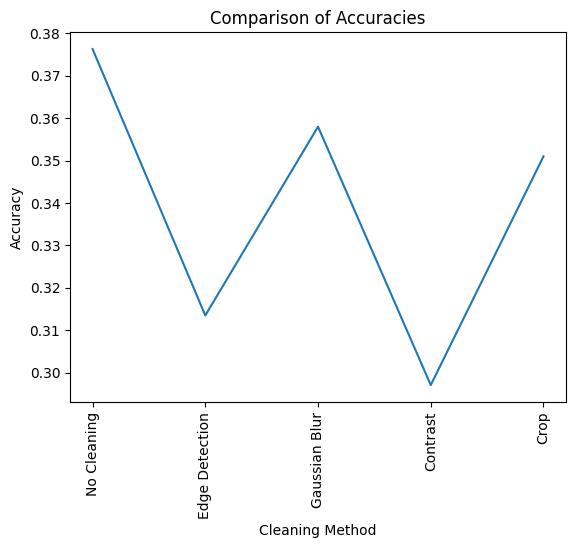

<Figure size 1200x1000 with 0 Axes>

In [14]:
plt.plot(["No Cleaning", "Edge Detection", "Gaussian Blur", "Contrast", "Crop"], [val[1] for val in listAllModels])
plt.title("Comparison of Accuracies")
plt.xlabel("Cleaning Method")
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.figure(figsize=(12, 10))
plt.show()

While for MNIST, contrast was the best of the lot, it's the worst here. However, Canny Edge Detection still seems like a poorer cleaning method.